# EfficientNetB0 Colab Training
This notebook assumes data preparation was completed locally and split artifacts were exported to `artifacts/splits/*.parquet`.

In [13]:
!pip install -q tensorflow scikit-learn pandas numpy

In [14]:
# Colab setup
from pathlib import Path, PurePosixPath
import random

import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive
from sklearn.utils import shuffle
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

SEED = 1234
IMG_SIZE = 224
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 30

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Configure paths in Google Drive
PROJECT_ROOT = Path('/content/drive/MyDrive/predicting-neurological-recovery')
SPLIT_ROOT = PROJECT_ROOT / 'artifacts' / 'splits'
IMAGE_ROOT = PROJECT_ROOT / 'exports' / 'mel_360x360' / 'train'
MODEL_OUTPUT_ROOT = PROJECT_ROOT / 'artifacts' / 'model_outputs'
MODEL_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('Split root:', SPLIT_ROOT)
print('Image root:', IMAGE_ROOT)
print('Model output root:', MODEL_OUTPUT_ROOT)

Split root: /content/drive/MyDrive/predicting-neurological-recovery/artifacts/splits
Image root: /content/drive/MyDrive/predicting-neurological-recovery/exports/mel_360x360/train
Model output root: /content/drive/MyDrive/predicting-neurological-recovery/artifacts/model_outputs


In [16]:
# Load prepared split artifacts
train_split_df = pd.read_parquet(SPLIT_ROOT / 'train_split.parquet')
val_split_df = pd.read_parquet(SPLIT_ROOT / 'val_split.parquet')
test_split_df = pd.read_parquet(SPLIT_ROOT / 'test_split.parquet')

for split_name, split_df in [('train', train_split_df), ('val', val_split_df), ('test', test_split_df)]:
    # Replace Windows-style backslashes with POSIX forward slashes
    split_df['relative_path'] = split_df['relative_path'].str.replace('\\', '/', regex=False)
    split_df['absolute_path'] = split_df['relative_path'].map(lambda path_value: str(IMAGE_ROOT / path_value))
    print(split_name, 'rows=', len(split_df), 'labels=', split_df['label'].value_counts().to_dict())

train rows= 15444 labels= {0: 9792, 1: 5652}
val rows= 828 labels= {0: 540, 1: 288}
test rows= 4050 labels= {0: 2538, 1: 1512}


In [17]:
# Build arrays for tf.data
train_x = train_split_df['absolute_path'].astype(str).to_numpy()
train_y = train_split_df['label'].to_numpy()
train_x, train_y = shuffle(train_x, train_y, random_state=SEED)

val_x = val_split_df['absolute_path'].astype(str).to_numpy()
val_y = val_split_df['label'].to_numpy()
test_x = test_split_df['absolute_path'].astype(str).to_numpy()
test_y = test_split_df['label'].to_numpy()

print('train:', train_x.shape, train_y.shape)
print('val:', val_x.shape, val_y.shape)
print('test:', test_x.shape, test_y.shape)

train: (15444,) (15444,)
val: (828,) (828,)
test: (4050,) (4050,)


In [18]:
# Build tf.data datasets
def load_image(file_path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image_bytes = tf.io.read_file(file_path)
    image = tf.image.decode_png(image_bytes, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices((train_x, train_y))
train_dataset = train_dataset.shuffle(buffer_size=len(train_x), reshuffle_each_iteration=True)
train_dataset = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

validation_dataset = tf.data.Dataset.from_tensor_slices((val_x, val_y))
validation_dataset = validation_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_x, test_y))
test_dataset = test_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [22]:
# Build and compile EfficientNetB0 with ImageNet weights
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 1. Load the base model pre-trained on ImageNet, excluding the top classification layer
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)

# 2. Add our own pooling and classification layer for 2 classes
x = layers.GlobalAveragePooling2D()(base_model.output)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 4,010,110 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [23]:
# Train with callbacks and save best checkpoint
checkpoint_path = MODEL_OUTPUT_ROOT / 'best_efficientnetb0.keras'
final_model_path = MODEL_OUTPUT_ROOT / 'final_efficientnetb0.keras'
history_path = MODEL_OUTPUT_ROOT / 'history.csv'

callbacks = [
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    verbose=1,
    callbacks=callbacks,
)

model.save(final_model_path)
pd.DataFrame(history.history).to_csv(history_path, index=False)
print('Saved:', checkpoint_path)
print('Saved:', final_model_path)
print('Saved:', history_path)

Epoch 1/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 3106s 6s/step - accuracy: 0.7310 - loss: 0.5240 - val_accuracy: 0.6522 - val_loss: 1.7926 - learning_rate: 0.0010
Epoch 2/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 80s 166ms/step - accuracy: 0.8409 - loss: 0.3560 - val_accuracy: 0.6486 - val_loss: 36.9065 - learning_rate: 0.0010
Epoch 3/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.9003 - loss: 0.2420 - val_accuracy: 0.6522 - val_loss: 0.9583 - learning_rate: 0.0010
Epoch 4/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - accuracy: 0.9328 - loss: 0.1712 - val_accuracy: 0.6208 - val_loss: 0.9023 - learning_rate: 0.0010
Epoch 5/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 82s 169ms/step - accuracy: 0.9501 - loss: 0.1300 - val_accuracy: 0.6618 - val_loss: 0.8438 - learning_rate: 0.0010
Epoch 6/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 80s 164ms/step - accuracy: 0.9566 - loss: 0.1093 - val_accuracy: 0.6522 - val_loss: 1.0625 - learning_rate: 0.0010
Epoch 7/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 78s 161ms/step - accuracy: 0.9

In [24]:
# Evaluate and export predictions
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)
probabilities = model.predict(test_dataset, verbose=1)
predicted_label = probabilities.argmax(axis=1)

test_results_df = test_split_df.copy()
test_results_df['predicted_label'] = predicted_label
test_results_df['prob_poor'] = probabilities[:, 0]
test_results_df['prob_good'] = probabilities[:, 1]

metrics_path = MODEL_OUTPUT_ROOT / 'test_metrics.csv'
predictions_path = MODEL_OUTPUT_ROOT / 'test_predictions.csv'
pd.DataFrame([{'test_loss': test_loss, 'test_accuracy': test_accuracy}]).to_csv(metrics_path, index=False)
test_results_df.to_csv(predictions_path, index=False)

print('Test accuracy:', test_accuracy)
print('Saved:', metrics_path)
print('Saved:', predictions_path)

127/127 ━━━━━━━━━━━━━━━━━━━━ 837s 7s/step - accuracy: 0.6296 - loss: 0.7766
127/127 ━━━━━━━━━━━━━━━━━━━━ 30s 180ms/step
Test accuracy: 0.6296296119689941
Saved: /content/drive/MyDrive/predicting-neurological-recovery/artifacts/model_outputs/test_metrics.csv
Saved: /content/drive/MyDrive/predicting-neurological-recovery/artifacts/model_outputs/test_predictions.csv


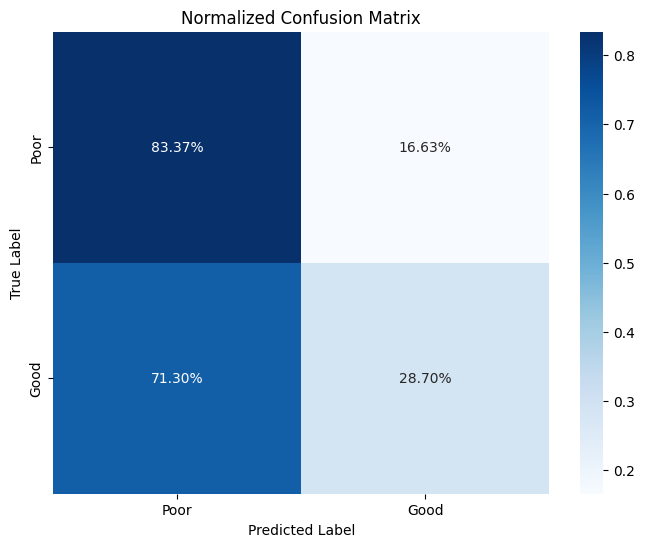

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
# Note: test_y are the true labels, predicted_label are the model predictions
cm = confusion_matrix(test_y, predicted_label)

# 2. Normalize the confusion matrix by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Define class labels (0: Poor, 1: Good)
class_names = ['Poor', 'Good']

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()